In [1]:
# ── Install required packages (run once) ──────────────────────────────
!pip install transformers torch scikit-learn beautifulsoup4 requests pandas numpy tqdm -q

In [2]:
# ── Core imports ───────────────────────────────────────────────────────
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import time
import re
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

# Hugging Face Transformers
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Device setup ───────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Libraries loaded successfully")
print(f"🖥️  Using device: {device}")

✅ Libraries loaded successfully
🖥️  Using device: cuda


In [3]:
# ── Category → MedlinePlus URL mapping ────────────────────────────────
CATEGORIES = {
    "Heart Disease" : "https://medlineplus.gov/heartdiseases.html",
    "Diabetes"      : "https://medlineplus.gov/diabetes.html",
    "Mental Health" : "https://medlineplus.gov/mentalhealth.html",
    "Cancer"        : "https://medlineplus.gov/cancer.html",
    "Nutrition"     : "https://medlineplus.gov/nutrition.html",
}

In [4]:
HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Educational Research Bot)'
}

In [5]:
def scrape_medlineplus(url, category, max_articles=40):
    """
    Scrapes health article headlines and summaries from a MedlinePlus topic page.
    Returns a list of dicts: {text, category}
    """
    articles = []
    try:
        response = requests.get(url, headers=HEADERS, timeout=15)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'html.parser')

        # MedlinePlus news items appear in <ul> with class 'ul-links-news'
        # and also in article summary sections — we grab both
        seen = set()

        # ── Method 1: News link items ──────────────────────────────────
        news_items = soup.select('ul.ul-links-news li a, #section-news li a')
        for item in news_items:
            text = item.get_text(strip=True)
            if len(text) > 30 and text not in seen:
                articles.append({'text': text, 'category': category})
                seen.add(text)

        # ── Method 2: Summary paragraphs & headers ─────────────────────
        summary_items = soup.select(
            '#section-summary p, #section-summary li, '
            '.section-body p, .topic-summary p'
        )
        for item in summary_items:
            text = item.get_text(strip=True)
            text = re.sub(r'\s+', ' ', text)
            if len(text) > 50 and text not in seen:
                articles.append({'text': text[:300], 'category': category})
                seen.add(text)

        # ── Method 3: Any <li> or <a> inside known content divs ────────
        fallback = soup.select('div#topic-summary li, div.section li')
        for item in fallback:
            text = item.get_text(strip=True)
            if len(text) > 40 and text not in seen:
                articles.append({'text': text[:300], 'category': category})
                seen.add(text)

    except Exception as e:
        print(f"  ⚠️  Could not scrape {url}: {e}")

    return articles[:max_articles]

In [6]:
# ── Scrape all categories ──────────────────────────────────────────────
print("🌐 Scraping MedlinePlus health topics...\n")
all_articles = []

🌐 Scraping MedlinePlus health topics...



In [7]:
for category, url in CATEGORIES.items():
  articles = scrape_medlineplus(url, category, max_articles=40)
  all_articles.extend(articles)
  print(f"  ✅  {category:20s} → {len(articles):3d} articles scraped")
  time.sleep(1)   # polite delay between requests

print(f"\n📦 Total raw articles scraped: {len(all_articles)}")

  ✅  Heart Disease        →  40 articles scraped
  ✅  Diabetes             →  40 articles scraped
  ✅  Mental Health        →  32 articles scraped
  ✅  Cancer               →  40 articles scraped
  ✅  Nutrition            →  40 articles scraped

📦 Total raw articles scraped: 192


In [8]:
print(all_articles[0])

{'text': 'Angina- chest pain from lack of blood flow', 'category': 'Heart Disease'}


In [9]:
# ── Curated seed samples (domain-expert backup) ────────────────────────
# These ensure each class has representative samples regardless of
# what was successfully scraped on the day of the session

SEED_SAMPLES = [
    # Heart Disease
    {"text": "High blood pressure increases the risk of heart attack and stroke significantly.", "category": "Heart Disease"},
    {"text": "Cholesterol plaques in coronary arteries can lead to chest pain and cardiac events.", "category": "Heart Disease"},
    {"text": "Atrial fibrillation is an irregular heartbeat that raises risk of blood clots.", "category": "Heart Disease"},
    {"text": "Cardiologists recommend regular ECG screening for patients over 50 years old.", "category": "Heart Disease"},
    {"text": "Heart failure occurs when the heart muscle cannot pump enough blood to meet the body needs.", "category": "Heart Disease"},
    {"text": "Bypass surgery restores blood flow to blocked coronary arteries in severe cases.", "category": "Heart Disease"},
    {"text": "Statins are prescribed to lower LDL cholesterol and reduce cardiovascular disease risk.", "category": "Heart Disease"},
    {"text": "A myocardial infarction happens when blood supply to part of the heart is cut off.", "category": "Heart Disease"},
    {"text": "Lifestyle changes including diet exercise and quitting smoking benefit heart health.", "category": "Heart Disease"},
    {"text": "Echocardiograms use ultrasound waves to create images of heart structure and function.", "category": "Heart Disease"},
    # Diabetes
    {"text": "Type 2 diabetes develops when cells become resistant to insulin and blood sugar rises.", "category": "Diabetes"},
    {"text": "Continuous glucose monitors help diabetic patients track blood sugar in real time.", "category": "Diabetes"},
    {"text": "Metformin is the first-line medication prescribed for managing type 2 diabetes.", "category": "Diabetes"},
    {"text": "Uncontrolled diabetes can lead to kidney damage nerve damage and vision loss.", "category": "Diabetes"},
    {"text": "HbA1c test measures average blood glucose levels over the past two to three months.", "category": "Diabetes"},
    {"text": "Insulin therapy is essential for patients with type 1 diabetes to survive.", "category": "Diabetes"},
    {"text": "Gestational diabetes occurs during pregnancy and can affect both mother and baby.", "category": "Diabetes"},
    {"text": "Diabetic retinopathy is a leading cause of blindness in working-age adults worldwide.", "category": "Diabetes"},
    {"text": "Regular foot care is critical for diabetic patients to prevent ulcers and amputations.", "category": "Diabetes"},
    {"text": "Low carbohydrate diets have shown promise in improving insulin sensitivity in diabetics.", "category": "Diabetes"},
    # Mental Health
    {"text": "Depression affects millions worldwide and is characterized by persistent sadness and loss of interest.", "category": "Mental Health"},
    {"text": "Cognitive behavioral therapy has strong evidence for treating anxiety and depression disorders.", "category": "Mental Health"},
    {"text": "Antidepressants like SSRIs work by increasing serotonin availability in the brain.", "category": "Mental Health"},
    {"text": "Post-traumatic stress disorder can develop after experiencing or witnessing a traumatic event.", "category": "Mental Health"},
    {"text": "Mindfulness meditation practice can reduce symptoms of anxiety and improve emotional regulation.", "category": "Mental Health"},
    {"text": "Schizophrenia is a severe mental disorder that affects how a person thinks feels and behaves.", "category": "Mental Health"},
    {"text": "Bipolar disorder involves extreme mood swings from depression to mania and hypomania.", "category": "Mental Health"},
    {"text": "Early intervention for mental health disorders leads to significantly better long-term outcomes.", "category": "Mental Health"},
    {"text": "Social isolation and loneliness are strongly linked to increased risk of mental illness.", "category": "Mental Health"},
    {"text": "Teletherapy and digital mental health apps have expanded access to psychological support.", "category": "Mental Health"},
    # Cancer
    {"text": "Chemotherapy targets rapidly dividing cells but also affects healthy tissue causing side effects.", "category": "Cancer"},
    {"text": "Breast cancer screening with mammography can detect tumors before symptoms appear.", "category": "Cancer"},
    {"text": "Immunotherapy harnesses the immune system to recognize and destroy cancer cells.", "category": "Cancer"},
    {"text": "Lung cancer is the leading cause of cancer death worldwide and is strongly linked to smoking.", "category": "Cancer"},
    {"text": "Prostate specific antigen PSA testing is used to screen for prostate cancer in men.", "category": "Cancer"},
    {"text": "Genetic mutations in BRCA1 and BRCA2 genes significantly increase breast cancer risk.", "category": "Cancer"},
    {"text": "Radiation therapy uses high energy beams to kill cancer cells and shrink tumors.", "category": "Cancer"},
    {"text": "Colorectal cancer rates are rising among younger adults under 50 years old.", "category": "Cancer"},
    {"text": "Targeted therapy drugs block specific molecules involved in cancer cell growth and spread.", "category": "Cancer"},
    {"text": "Palliative care focuses on providing relief from symptoms and improving quality of life.", "category": "Cancer"},
    # Nutrition
    {"text": "A Mediterranean diet rich in olive oil fish and vegetables reduces chronic disease risk.", "category": "Nutrition"},
    {"text": "Excessive sugar consumption is linked to obesity type 2 diabetes and fatty liver disease.", "category": "Nutrition"},
    {"text": "Omega-3 fatty acids found in fish and flaxseed support brain and cardiovascular health.", "category": "Nutrition"},
    {"text": "Vitamin D deficiency is associated with bone loss immune dysfunction and depression.", "category": "Nutrition"},
    {"text": "Dietary fiber from whole grains legumes and vegetables promotes gut microbiome health.", "category": "Nutrition"},
    {"text": "Ultra-processed foods high in sodium and trans fats increase cardiovascular disease risk.", "category": "Nutrition"},
    {"text": "Iron deficiency anemia is the most common nutritional deficiency globally affecting billions.", "category": "Nutrition"},
    {"text": "Antioxidants in fruits and vegetables protect cells from oxidative stress and inflammation.", "category": "Nutrition"},
    {"text": "Intermittent fasting has shown potential benefits for weight loss and metabolic health.", "category": "Nutrition"},
    {"text": "Adequate protein intake is essential for muscle repair immune function and hormone production.", "category": "Nutrition"},
]

print(f"📌 Curated seed samples ready: {len(SEED_SAMPLES)}")

📌 Curated seed samples ready: 50


In [10]:
df_scraped = pd.DataFrame(all_articles)

In [11]:
df_seed    = pd.DataFrame(SEED_SAMPLES)

In [12]:
df         = pd.concat([df_scraped, df_seed], ignore_index=True)

In [13]:
df.head()

,text,category
0,Angina- chest pain from lack of blood flow,Heart Disease
1,Heart attacks- when part of the heart muscle d...,Heart Disease
2,Heart failure- when your heart can't pump enou...,Heart Disease
3,Arrhythmia- a problem with the rate or rhythm ...,Heart Disease
4,Age.Your risk of heart disease goes up as you ...,Heart Disease


In [14]:
# ── Basic cleaning ─────────────────────────────────────────────────────
df['text'] = df['text'].str.strip()
df = df[df['text'].str.len() > 30]   # remove very short entries
df = df.drop_duplicates(subset='text').reset_index(drop=True)

print("📊 Dataset Summary")
print("=" * 40)
print(f"Total samples : {len(df)}")
print(f"Scraped        : {len(df_scraped)}")
print(f"Seed samples   : {len(df_seed)}")
print()
print("Samples per category:")
print(df['category'].value_counts())

📊 Dataset Summary
Total samples : 241
Scraped        : 192
Seed samples   : 50

Samples per category:
category
Heart Disease    50
Diabetes         50
Cancer           50
Nutrition        49
Mental Health    42
Name: count, dtype: int64


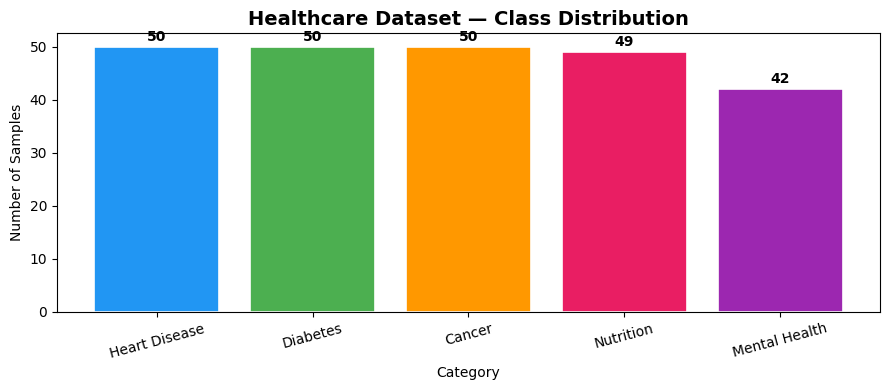

In [15]:
plt.figure(figsize=(9, 4))
counts = df['category'].value_counts()
colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontweight='bold')
plt.title('Healthcare Dataset — Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Number of Samples')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [16]:
df.head()

,text,category
0,Angina- chest pain from lack of blood flow,Heart Disease
1,Heart attacks- when part of the heart muscle d...,Heart Disease
2,Heart failure- when your heart can't pump enou...,Heart Disease
3,Arrhythmia- a problem with the rate or rhythm ...,Heart Disease
4,Age.Your risk of heart disease goes up as you ...,Heart Disease


In [17]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

In [18]:
df.head()

,text,category,label
0,Angina- chest pain from lack of blood flow,Heart Disease,2
1,Heart attacks- when part of the heart muscle d...,Heart Disease,2
2,Heart failure- when your heart can't pump enou...,Heart Disease,2
3,Arrhythmia- a problem with the rate or rhythm ...,Heart Disease,2
4,Age.Your risk of heart disease goes up as you ...,Heart Disease,2


In [19]:
NUM_CLASSES = len(le.classes_)
LABEL_MAP   = dict(enumerate(le.classes_))

In [20]:
print("🏷️  Label Encoding Map:")
for idx, name in LABEL_MAP.items():
    print(f"   {idx} → {name}")

🏷️  Label Encoding Map:
   0 → Cancer
   1 → Diabetes
   2 → Heart Disease
   3 → Mental Health
   4 → Nutrition


In [21]:
# ── Train / Validation / Test split ───────────────────────────────────
X = df['text'].tolist()
y = df['label'].tolist()



In [22]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
# 70 Training
# 30 Temp 50%
# -> Testing
# -> Validation

In [23]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [24]:
print(f"\n✂️  Data Split:")
print(f"   Train      : {len(X_train)} samples (70%)")
print(f"   Validation : {len(X_val)} samples (15%)")
print(f"   Test       : {len(X_test)} samples (15%)")


✂️  Data Split:
   Train      : 168 samples (70%)
   Validation : 36 samples (15%)
   Test       : 37 samples (15%)


In [25]:
MODEL_NAME   = 'bert-base-uncased'
MAX_LEN      = 128    # max token length per sample

In [27]:
print(f"⏳ Loading tokenizer: {MODEL_NAME} ...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print("✅ Tokenizer loaded")

⏳ Loading tokenizer: bert-base-uncased ...
✅ Tokenizer loaded


In [28]:
# ── Demonstrate tokenization on one example ────────────────────────────
sample_text = "High blood pressure increases the risk of heart attack and stroke."

In [29]:
encoded = tokenizer(
    sample_text,
    max_length=MAX_LEN,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

In [30]:
print("\n📝 Tokenization Demo:")
print(f"   Original text    : {sample_text}")
print(f"   Token IDs (first 15): {encoded['input_ids'][0][:15].tolist()}")
print(f"   Decoded tokens   : {tokenizer.convert_ids_to_tokens(encoded['input_ids'][0][:15].tolist())}")
print(f"   Attention mask   : {encoded['attention_mask'][0][:15].tolist()}")
print(f"   [CLS]=101 at pos 0, [SEP]=102 at end")


📝 Tokenization Demo:
   Original text    : High blood pressure increases the risk of heart attack and stroke.
   Token IDs (first 15): [101, 2152, 2668, 3778, 7457, 1996, 3891, 1997, 2540, 2886, 1998, 6909, 1012, 102, 0]
   Decoded tokens   : ['[CLS]', 'high', 'blood', 'pressure', 'increases', 'the', 'risk', 'of', 'heart', 'attack', 'and', 'stroke', '.', '[SEP]', '[PAD]']
   Attention mask   : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
   [CLS]=101 at pos 0, [SEP]=102 at end


In [31]:
class HealthcareDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
      text  = str(self.texts[idx])
      label = self.labels[idx]

      encoding = self.tokenizer(
          text,
          max_length=self.max_len,
          padding='max_length',
          truncation=True,
          return_tensors='pt'
      )

      return {
          'input_ids'      : encoding['input_ids'].squeeze(0),       # [MAX_LEN]
          'attention_mask' : encoding['attention_mask'].squeeze(0),  # [MAX_LEN]
          'label'          : torch.tensor(label, dtype=torch.long)
      }


In [33]:
BATCH_SIZE = 16

train_dataset = HealthcareDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = HealthcareDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = HealthcareDataset(X_test,  y_test,  tokenizer, MAX_LEN)

In [34]:
# ── Create DataLoaders ─────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [35]:
print(f"✅ Datasets created")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

✅ Datasets created
   Train batches : 11
   Val batches   : 3
   Test batches  : 3


In [36]:
# ── Inspect one batch ──────────────────────────────────────────────────
sample_batch = next(iter(train_loader))
print(f"\n🔍 One batch shape:")
print(f"   input_ids      : {sample_batch['input_ids'].shape}")
print(f"   attention_mask : {sample_batch['attention_mask'].shape}")
print(f"   labels         : {sample_batch['label'].shape}")


🔍 One batch shape:
   input_ids      : torch.Size([16, 128])
   attention_mask : torch.Size([16, 128])
   labels         : torch.Size([16])


In [37]:
# ── Load pre-trained BERT with classification head ─────────────────────
print(f"⏳ Loading {MODEL_NAME} for sequence classification...")

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    output_attentions=False,
    output_hidden_states=False
)
model = model.to(device)


⏳ Loading bert-base-uncased for sequence classification...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [38]:
# ── Model summary ──────────────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✅ BERT model loaded")
print(f"   Total parameters     : {total_params:,}")
print(f"   Trainable parameters : {trainable_params:,}")
print(f"   Classification head  : 768 → {NUM_CLASSES} classes")
print(f"   Device               : {device}")


✅ BERT model loaded
   Total parameters     : 109,486,085
   Trainable parameters : 109,486,085
   Classification head  : 768 → 5 classes
   Device               : cuda


In [39]:
# ── Hyperparameters ────────────────────────────────────────────────────
EPOCHS       = 4
LEARNING_RATE = 2e-5     # standard BERT fine-tuning LR
WARMUP_RATIO  = 0.1      # 10% of steps for warmup

In [40]:
total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)


In [41]:

# ── Optimizer & Scheduler ──────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, eps=1e-8)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

In [42]:

print(f"⚙️  Training Configuration:")
print(f"   Epochs         : {EPOCHS}")
print(f"   Batch size     : {BATCH_SIZE}")
print(f"   Learning rate  : {LEARNING_RATE}")
print(f"   Total steps    : {total_steps}")
print(f"   Warmup steps   : {warmup_steps}")

⚙️  Training Configuration:
   Epochs         : 4
   Batch size     : 16
   Learning rate  : 2e-05
   Total steps    : 44
   Warmup steps   : 4


In [43]:
# ── Helper: evaluate on any DataLoader ────────────────────────────────
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)

            total_loss += outputs.loss.item()
            preds       = torch.argmax(outputs.logits, dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy, all_preds, all_labels




In [45]:

# ── Training loop ──────────────────────────────────────────────────────
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_acc  = 0.0
best_model_path = 'best_bert_healthcare.pt'



In [48]:
print("🚀 Starting Training...\n")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>9} | {'Val Acc':>8}")
print("-" * 60)
for epoch in range(1, EPOCHS + 1):
    # ── Training phase ─────────────────────────────────────────────────
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)

        loss = outputs.loss
        loss.backward()

        # Gradient clipping — prevents exploding gradients in Transformers
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = torch.argmax(outputs.logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total

    # ── Validation phase ───────────────────────────────────────────────
    val_loss, val_acc, _, _ = evaluate(model, val_loader)

    # ── Save best model ────────────────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        saved_marker = " ✅ saved"
    else:
        saved_marker = ""

    # ── Log ────────────────────────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.2%} | {val_loss:>9.4f} | {val_acc:>7.2%}{saved_marker}")

print(f"\n🏆 Best Validation Accuracy: {best_val_acc:.2%}")

🚀 Starting Training...

 Epoch | Train Loss | Train Acc |  Val Loss |  Val Acc
------------------------------------------------------------


     1 |     1.5841 |   27.38% |    1.5365 |  38.89% ✅ saved


     2 |     1.4701 |   47.62% |    1.4904 |  50.00% ✅ saved


     3 |     1.3337 |   60.12% |    1.4223 |  61.11% ✅ saved


     4 |     1.2777 |   66.67% |    1.3917 |  58.33%

🏆 Best Validation Accuracy: 61.11%


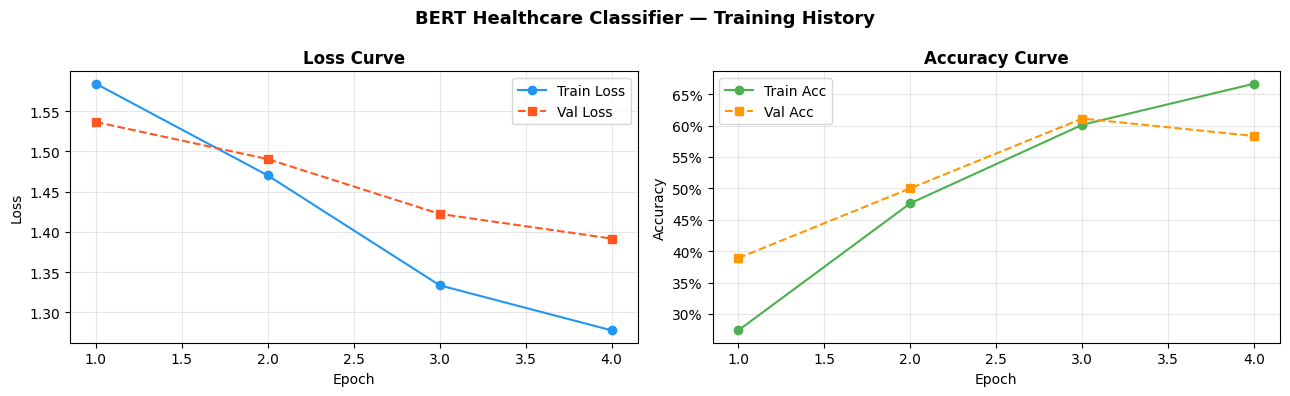

In [49]:
# ── Plot training curves ───────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss curve
axes[0].plot(epochs_range, history['train_loss'], 'o-', color='#2196F3', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   's--', color='#FF5722', label='Val Loss')
axes[0].set_title('Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy curve
axes[1].plot(epochs_range, history['train_acc'], 'o-', color='#4CAF50', label='Train Acc')
axes[1].plot(epochs_range, history['val_acc'],   's--', color='#FF9800', label='Val Acc')
axes[1].set_title('Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('BERT Healthcare Classifier — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [50]:
model.load_state_dict(torch.load(best_model_path, map_location=device))

<All keys matched successfully>

In [51]:
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader)

print(f"🧪 Test Set Results")
print(f"   Test Loss     : {test_loss:.4f}")
print(f"   Test Accuracy : {test_acc:.2%}")

# ── Classification Report ──────────────────────────────────────────────
class_names = le.classes_
print("\n📊 Classification Report:")
print(classification_report(test_labels, test_preds, target_names=class_names))

🧪 Test Set Results
   Test Loss     : 1.3528
   Test Accuracy : 51.35%

📊 Classification Report:
               precision    recall  f1-score   support

       Cancer       1.00      0.25      0.40         8
     Diabetes       0.36      0.71      0.48         7
Heart Disease       0.36      0.50      0.42         8
Mental Health       0.67      0.33      0.44         6
    Nutrition       0.86      0.75      0.80         8

     accuracy                           0.51        37
    macro avg       0.65      0.51      0.51        37
 weighted avg       0.66      0.51      0.51        37



In [52]:
# ── Test on new unseen sentences ───────────────────────────────────────
test_sentences = [
    "The patient was prescribed insulin therapy after being diagnosed with type 1 diabetes.",
    "MRI scan revealed a malignant tumor in the left lung requiring immediate chemotherapy.",
    "The doctor recommended a diet rich in leafy greens and omega-3 fatty acids.",
    "She was experiencing severe chest pain and shortness of breath indicating possible cardiac arrest.",
    "The therapist suggested cognitive behavioral therapy for managing panic attacks and depression.",
    "Blood glucose levels were dangerously high at 450 mg/dL requiring emergency insulin.",
]

In [53]:
def predict(text, model, tokenizer, label_map, max_len=128):
    """
    Predict the healthcare category of a given text string.
    Returns predicted label, confidence score, and all class probabilities.
    """
    model.eval()
    encoding = tokenizer(
        text,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    probs      = torch.softmax(outputs.logits, dim=1).squeeze().cpu().numpy()
    pred_idx   = int(np.argmax(probs))
    pred_label = label_map[pred_idx]
    confidence = float(probs[pred_idx])

    return pred_label, confidence, {label_map[i]: round(float(p), 4) for i, p in enumerate(probs)}

In [54]:
for text in test_sentences:
    label, conf, all_probs = predict(text, model, tokenizer, LABEL_MAP)
    short_text = text[:65] + "..." if len(text) > 65 else text
    print(f"\nText       : {short_text}")
    print(f"Prediction : {label:<20}  Confidence: {conf:.2%}")
    print(f"All probs  : ", end="")
    for cat, prob in sorted(all_probs.items(), key=lambda x: -x[1]):
        print(f"{cat}: {prob:.2%}", end="  ")
    print()


Text       : The patient was prescribed insulin therapy after being diagnosed ...
Prediction : Diabetes              Confidence: 24.34%
All probs  : Diabetes: 24.34%  Cancer: 21.96%  Mental Health: 21.03%  Heart Disease: 18.52%  Nutrition: 14.14%  

Text       : MRI scan revealed a malignant tumor in the left lung requiring im...
Prediction : Diabetes              Confidence: 25.00%
All probs  : Diabetes: 25.00%  Cancer: 21.65%  Heart Disease: 20.95%  Mental Health: 19.81%  Nutrition: 12.60%  

Text       : The doctor recommended a diet rich in leafy greens and omega-3 fa...
Prediction : Heart Disease         Confidence: 24.01%
All probs  : Heart Disease: 24.01%  Diabetes: 20.27%  Cancer: 20.25%  Nutrition: 18.42%  Mental Health: 17.06%  

Text       : She was experiencing severe chest pain and shortness of breath in...
Prediction : Diabetes              Confidence: 24.92%
All probs  : Diabetes: 24.92%  Mental Health: 21.79%  Cancer: 21.45%  Heart Disease: 20.10%  Nutrition: 11.75%  


In [ ]:
# ── Interactive: try your own text ────────────────────────────────────
print("💬 Try your own healthcare text:")
print("   (Edit the text below and run the cell)\n")

my_text = "Radiation therapy was used to shrink the tumor before surgery."

label, conf, all_probs = predict(my_text, model, tokenizer, LABEL_MAP)

print(f"Input      : {my_text}")
print(f"Prediction : {label}")
print(f"Confidence : {conf:.2%}")
print("\nAll class probabilities:", end="")
for cat, prob in sorted(all_probs.items(), key=lambda x: -x[1]):
    print(f"{cat}: {prob:.2%}", end="  ")
print()

💬 Try your own healthcare text:
   (Edit the text below and run the cell)

Input      : Radiation therapy was used to shrink the tumor before surgery.
Prediction : Diabetes
Confidence : 24.35%

All class probabilities:
